# Importing Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from matplotlib import pyplot as plt
from os import listdir
from os.path import isfile, join
from scipy.stats import kurtosis, skew

# Function to Create a new dataframe

In [2]:
def create_empty_df():
    df = pd.DataFrame()
    
    df['red_mean'] = None
    df['green_mean'] = None
    df['blue_mean'] = None
    df['amt_green'] = None
    df['amt_non_green'] = None
    df['red_std'] = None
    df['green_std'] = None
    df['blue_std'] = None        
    df['red_var'] = None
    df['green_var'] = None
    df['blue_var'] = None 
    df['red_kurt'] = None
    df['red_skew'] = None
    df['green_kurt'] = None
    df['green_skew'] = None
    df['blue_kurt'] = None
    df['blue_skew'] = None
    
    df['fcontrast'] = None
    df['fdissimilarity'] = None
    df['fhomogeneity'] = None
    df['fenergy'] = None
    df['fcorrelation'] = None
    
    df['label'] = None
    return df

# Preprocessing and  feature extraction

In [3]:


def feature_extractor(filename,label):
   
    original_image = cv2.imread(filename)
    image = cv2.resize(original_image, (350, 350))
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    if label == 0: 
        l_thresh_min = 35
        l_thresh_max = 160
        a_thresh_min = 135
        a_thresh_max = 185
        b_thresh_min = 100
        b_thresh_max = 160
    elif label == 1: 
        l_thresh_min = 30
        l_thresh_max = 200
        a_thresh_min = 125
        a_thresh_max = 200
        b_thresh_min = 100
        b_thresh_max = 180
    elif label == 2: 
        l_thresh_min = 35
        l_thresh_max = 260
        a_thresh_min = 235
        a_thresh_max = 185
        b_thresh_min = 100
        b_thresh_max = 160

    if label!=3:
        l_mask = cv2.inRange(lab_image[:, :, 0], l_thresh_min, l_thresh_max)
        a_mask = cv2.inRange(lab_image[:, :, 1], a_thresh_min, a_thresh_max)
        b_mask = cv2.inRange(lab_image[:, :, 2], b_thresh_min, b_thresh_max)
        initial_mask = cv2.bitwise_and(l_mask, cv2.bitwise_and(a_mask, b_mask))

    l_channel, a_channel, b_channel = cv2.split(lab_image)
    clip_limit=1.0
    tile_grid_size=(4, 4)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    clahe_l_channel = clahe.apply(l_channel)
    lab = cv2.merge([clahe_l_channel, a_channel, b_channel])
    rgbimg = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    ab = lab[:, :, 1:].reshape(-1, 2).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    flags = cv2.KMEANS_PP_CENTERS
    
    K=3
    _, labels, centers = cv2.kmeans(ab, K, None, criteria, 10, flags)
    mean_vals = np.zeros((K, 2))
    for i in range(K):
        mean_vals[i] = np.mean(ab[labels.flatten() == i], axis=0)
    overall_mean = np.mean(ab, axis=0)
    affected_cluster = np.argmin(np.linalg.norm(mean_vals - overall_mean, axis=1))
    affected_mask = np.uint8(labels.reshape(rgbimg.shape[:2]) == affected_cluster)

    if label==3:
        img1 = cv2.bitwise_and(image, image, mask=affected_mask)
    
    else:
        final_mask = cv2.bitwise_and(initial_mask, affected_mask)
        img1 = cv2.bitwise_and(image, image, mask=final_mask)
        
    red_channel = img1[:,:,0]
    green_channel = img1[:,:,1] 
    blue_channel = img1[:,:,2]

    red_mean = np.mean(red_channel)
    green_mean = np.mean(green_channel)
    blue_mean = np.mean(blue_channel)
       
    red_std = np.std(red_channel)
    green_std = np.std(green_channel)
    blue_std = np.std(blue_channel)
    
    red_var = red_std**2 
    green_var =green_std**2
    blue_var = blue_std**2
 
    red_kurt = kurtosis(red_channel.flatten())
    red_skew = skew(red_channel.flatten())

    green_kurt = kurtosis(green_channel.flatten())
    green_skew = skew(green_channel.flatten())

    blue_kurt = kurtosis(blue_channel.flatten())
    blue_skew = skew(blue_channel.flatten())
    
   
    gr = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(gr, (36, 0, 0), (70, 255,255))
    ratio_green = cv2.countNonZero(mask)/(img1.size/3)
    amt_green=np.round(ratio_green, 2)
 
    amt_non_green=1-amt_green
    img2 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g=graycomatrix(img2, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4])
    contrast = graycoprops(g, 'contrast')
    fcontrast=contrast[0][0]+contrast[0][1]+contrast[0][2]+contrast[0][3]
    
    dissimilarity = graycoprops(g, prop='dissimilarity')
    fdissimilarity=dissimilarity[0][0]+dissimilarity[0][1]+dissimilarity[0][2]+dissimilarity[0][3]

    homogeneity = graycoprops(g, prop='homogeneity')
    fhomogeneity=homogeneity[0][0]+homogeneity[0][1]+homogeneity[0][2]+homogeneity[0][3]
    energy = graycoprops(g, prop='energy')
    fenergy=energy[0][0]+energy[0][1]+energy[0][2]+energy[0][3]
  
    correlation = graycoprops(g,prop= 'correlation')
    fcorrelation=correlation[0][0]+correlation[0][1]+correlation[0][2]+correlation[0][3]

  
    l = [red_mean, green_mean, blue_mean,amt_green, amt_non_green, red_std, green_std, blue_std,
         red_var, green_var, blue_var,red_kurt,red_skew,green_kurt,green_skew,blue_kurt,blue_skew,
         fcontrast,fdissimilarity,fhomogeneity,fenergy,fcorrelation
    ]
    return l

# Function to process one folder

In [4]:
def process_folder(folderpath,df_f,label_f):

    imagelist = os.listdir(folderpath)  
    for image in imagelist:
        imagepath = os.path.join(folderpath, image)
        #print(imagepath)
        im_feature = feature_extractor(imagepath,label_f) 
        if im_feature == "Invalid":
            continue
        im_feature.append(label_f) 
        df_f.loc[len(df_f)] = im_feature 
        
    return df_f


In [5]:
def process_fruit(folderpaths, labels, savepath):
    datasheet = create_empty_df()
    for i in range(len(folderpaths)):
        datasheet = process_folder(folderpaths[i],datasheet,labels[i])

    datasheet.to_excel(savepath)

    return None

# Orange

In [6]:
folderpaths = ['C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/train/blackspot',
               'C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/train/canker',
               'C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/train/fresh',
               'C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/train/grenning'

]

labels = [0,1,2,3]
savepath = 'C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/proccessed dataset/orangeDisease9.xlsx'
process_fruit(folderpaths, labels, savepath)

# Feature Ranking and Selection

D:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Feature Ranking based on Total Importance:
Rank 1: Feature red_std, Importance Score: 5.731075248807623
Rank 2: Feature fcorrelation, Importance Score: 5.088987591377595
Rank 3: Feature blue_std, Importance Score: 3.3874024470087223
Rank 4: Feature fhomogeneity, Importance Score: 2.880107182059595
Rank 5: Feature fcontrast, Importance Score: 2.864423233909269
Rank 6: Feature fenergy, Importance Score: 2.6984955169740186
Rank 7: Feature amt_green, Importance Score: 1.355596964855113
Rank 8: Feature amt_non_green, Importance Score: 1.355596964855113
Rank 9: Feature green_mean, Importance Score: 1.1362346340020217
Rank 10: Feature fdissimilarity, Importance Score: 0.9629291181273678
Rank 11: Feature green_var, Importance Score: 0.532124037293671
Rank 12: Feature green_std, Importance Score: 0.34952491233155863
Rank 13: Feature blue_skew, Importance Score: 0.08792995176673997
Rank 14: Feature red_kurt, Importance Score: 0.005072491174054917
Rank 15: Feature red_var, Importance Score: 0.0
R

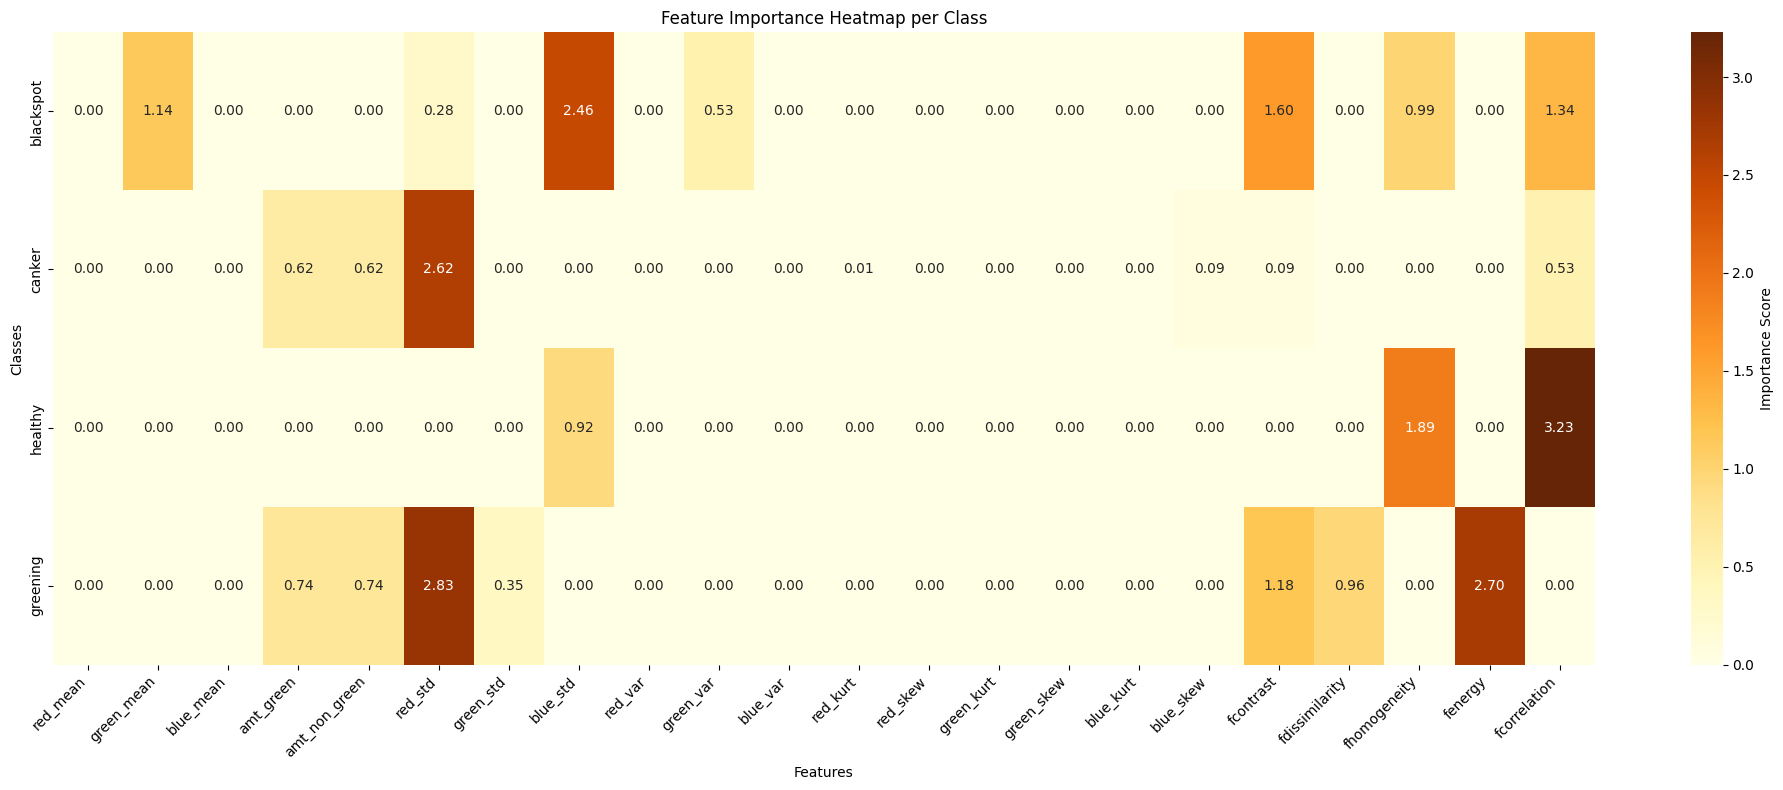

In [2]:
import numpy as np
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

df = pd.read_excel(
    'C:/Users/maruf/prac_Orange_disease_detection/FruitDataset/proccessed dataset/orangeDisease9.xlsx'
)

features = [
    'red_mean', 'green_mean', 'blue_mean',
    'amt_green', 'amt_non_green',
    'red_std', 'green_std', 'blue_std',
    'red_var', 'green_var', 'blue_var',
    'red_kurt', 'red_skew',
    'green_kurt', 'green_skew',
    'blue_kurt', 'blue_skew',
    'fcontrast', 'fdissimilarity',
    'fhomogeneity', 'fenergy', 'fcorrelation'
]

X = df[features]
y = df['label']


np.random.seed(5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5, stratify=y
)


imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)


scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_imp)
X_test_std = scaler.transform(X_test_imp)


X_train_std = np.round(X_train_std, 2)
X_test_std = np.round(X_test_std, 2)

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')


lasso = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.1,
    multi_class='ovr',
    random_state=5,
    max_iter=50
)

lasso.fit(X_train_std, y_train)


feature_importance = np.abs(lasso.coef_)
total_importance = np.sum(feature_importance, axis=0)

sorted_indices = np.argsort(total_importance)[::-1]
feature_ranked = [features[idx] for idx in sorted_indices]

print("Feature Ranking based on Total Importance:")
for i, idx in enumerate(sorted_indices):
    print(f"Rank {i+1}: Feature {features[idx]}, Importance Score: {total_importance[idx]}")

print("\nFinal Feature Ranking List:")
print(feature_ranked)

# =========================
# Heatmap
# =========================
clsF = ['blackspot', 'canker', 'healthy', 'greening']

plt.figure(figsize=(20, 8))
sns.heatmap(
    feature_importance,
    annot=True,
    fmt=".2f",
    cmap="YlOrBr",
    xticklabels=features,
    yticklabels=clsF,
    cbar_kws={'label': 'Importance Score'}
)

plt.title("Feature Importance Heatmap per Class")
plt.xlabel("Features")
plt.ylabel("Classes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [3]:


top_n_features = 7
top_features_per_class = {}

for i, cls in enumerate(clsF):
    class_importance = feature_importance[i]
    top_indices = np.argsort(class_importance)[-top_n_features:][::-1]   
    top_features = [(features[idx], class_importance[idx]) for idx in top_indices]
    top_features_per_class[cls] = top_features

for cls, top_features in top_features_per_class.items():
    print(f"\nTop {top_n_features} features for {cls}:")
    for feature, score in top_features:
        print(f"Feature: {feature}, Importance Score: {score}")
        

feature_vector_blackspot = []
feature_vector_canker = []
feature_vector_healthy = []
feature_vector_greening = []

for i, cls in enumerate(clsF):
    class_importance = feature_importance[i]
    top_indices = np.argsort(class_importance)[-top_n_features:][::-1]
    top_features = [features[idx] for idx in top_indices]

    if cls == 'blackspot':
        feature_vector_blackspot = top_features
    elif cls == 'canker':
        feature_vector_canker = top_features
    elif cls == 'healthy':
        feature_vector_healthy = top_features
    elif cls == 'greening':
        feature_vector_greening = top_features



feature_vector_union_all = set(feature_vector_blackspot) | set(feature_vector_canker) | set(feature_vector_healthy) | set(feature_vector_greening)
feature_vector_intersection_all = set(feature_vector_blackspot) & set(feature_vector_canker) & set(feature_vector_healthy) & set(feature_vector_greening)
Uncommon_feature=set(feature_ranked[0:14])^feature_vector_union_all 
feature_vector_union_all=list(feature_vector_union_all)
feature_vector_intersection_all=list(feature_vector_intersection_all)
Uncommon_feature_all=list(Uncommon_feature)
final_feature_vector=feature_vector_union_all | feature_vector_intersection_all | Uncommon_feature_all
print("\n\nFinal feature set:", final_feature_vector)




Top 7 features for blackspot:
Feature: blue_std, Importance Score: 2.4642224014991214
Feature: fcontrast, Importance Score: 1.6032109083142305
Feature: fcorrelation, Importance Score: 1.3356166938331273
Feature: green_mean, Importance Score: 1.1362346340020217
Feature: fhomogeneity, Importance Score: 0.9883752484160565
Feature: green_var, Importance Score: 0.532124037293671
Feature: red_std, Importance Score: 0.27892451618629244

Top 7 features for canker:
Feature: red_std, Importance Score: 2.624479227123416
Feature: amt_non_green, Importance Score: 0.618737743172697
Feature: amt_green, Importance Score: 0.618737743172697
Feature: fcorrelation, Importance Score: 0.5253111253420448
Feature: blue_skew, Importance Score: 0.08792995176673997
Feature: fcontrast, Importance Score: 0.08557924385816919
Feature: red_kurt, Importance Score: 0.005072491174054917

Top 7 features for healthy:
Feature: fcorrelation, Importance Score: 3.228059772202423
Feature: fhomogeneity, Importance Score: 1.891